<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [9]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [10]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [11]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [12]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



,serie,fecha_inicio,fecha_fin,observaciones,nulos,promedio,minimo,maximo
0,y_s1 - Introduction,2015-01-04,2021-11-28,361,0,26.437394,20.255319,31.702479
1,y_s2 - Méfait,2015-01-04,2021-11-28,361,0,26.389151,21.660870,33.220588
2,y_s3 - Vol dans / sur véhicule à moteur,2015-01-04,2021-11-28,361,0,25.791971,21.031915,31.732759
3,y_s4 - Vol de véhicule à moteur,2015-01-04,2021-11-28,361,0,27.460034,21.093750,32.365591


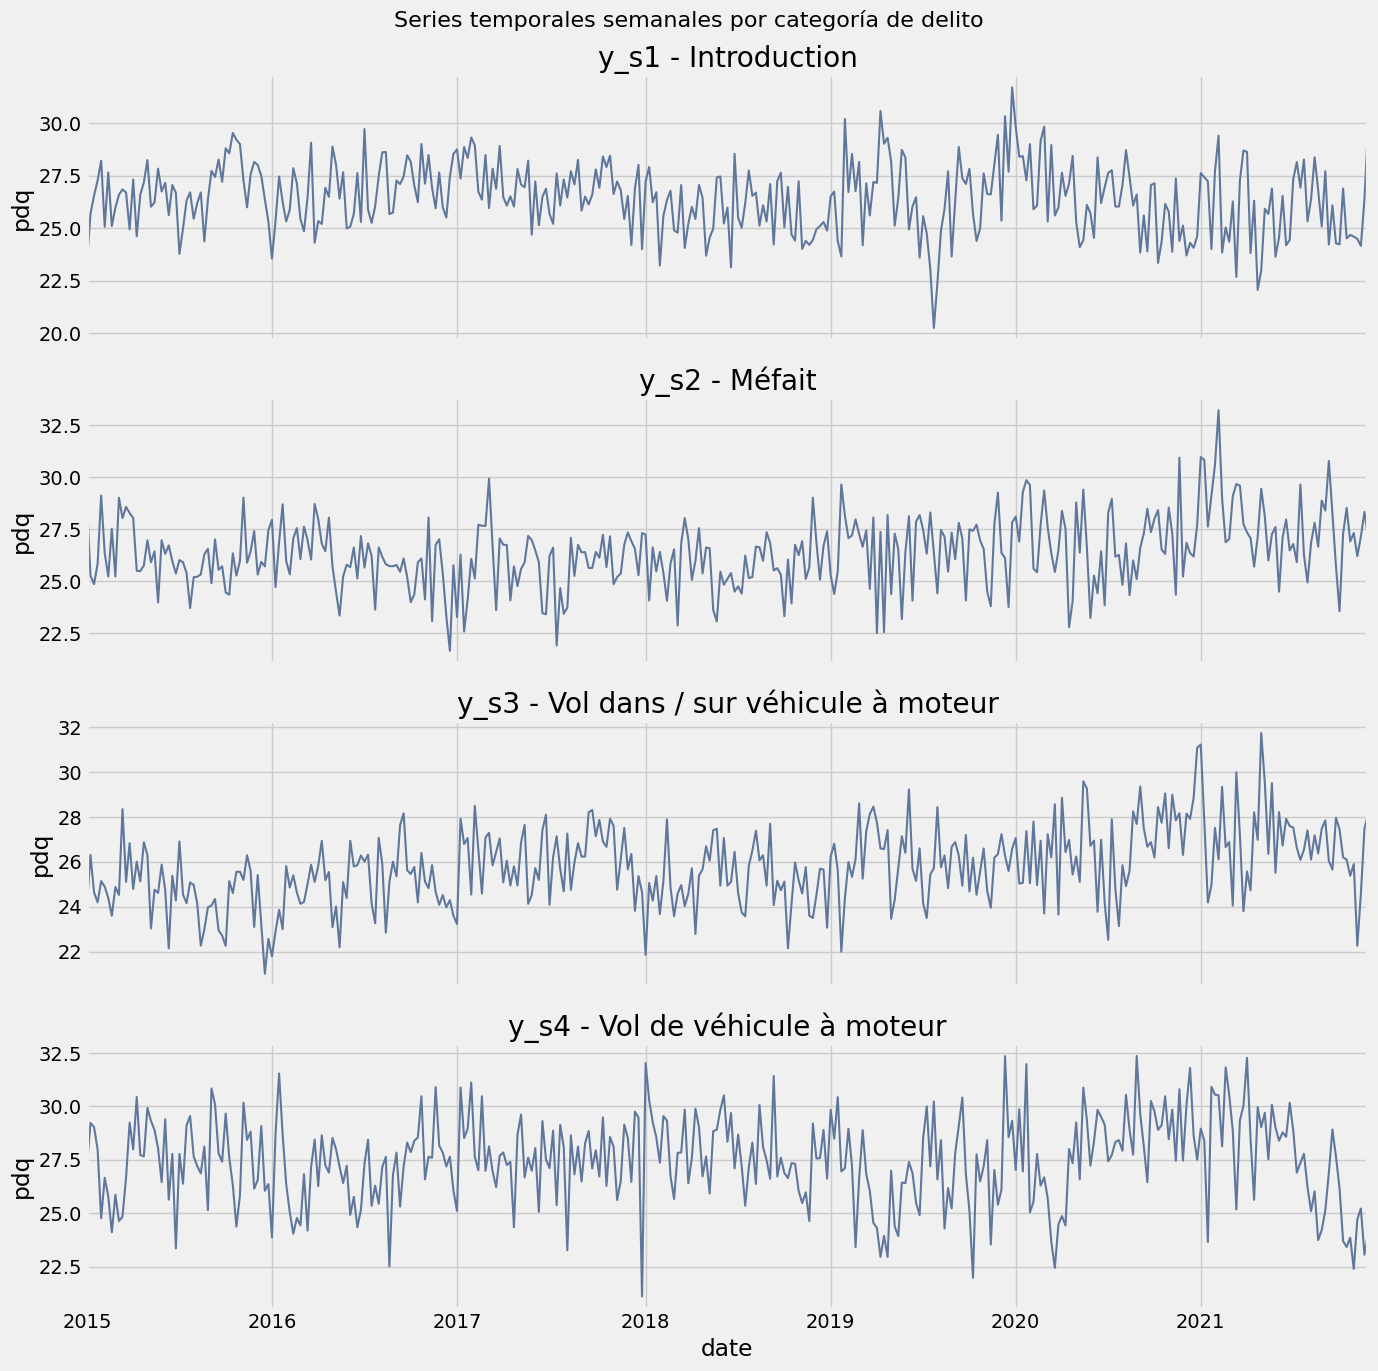

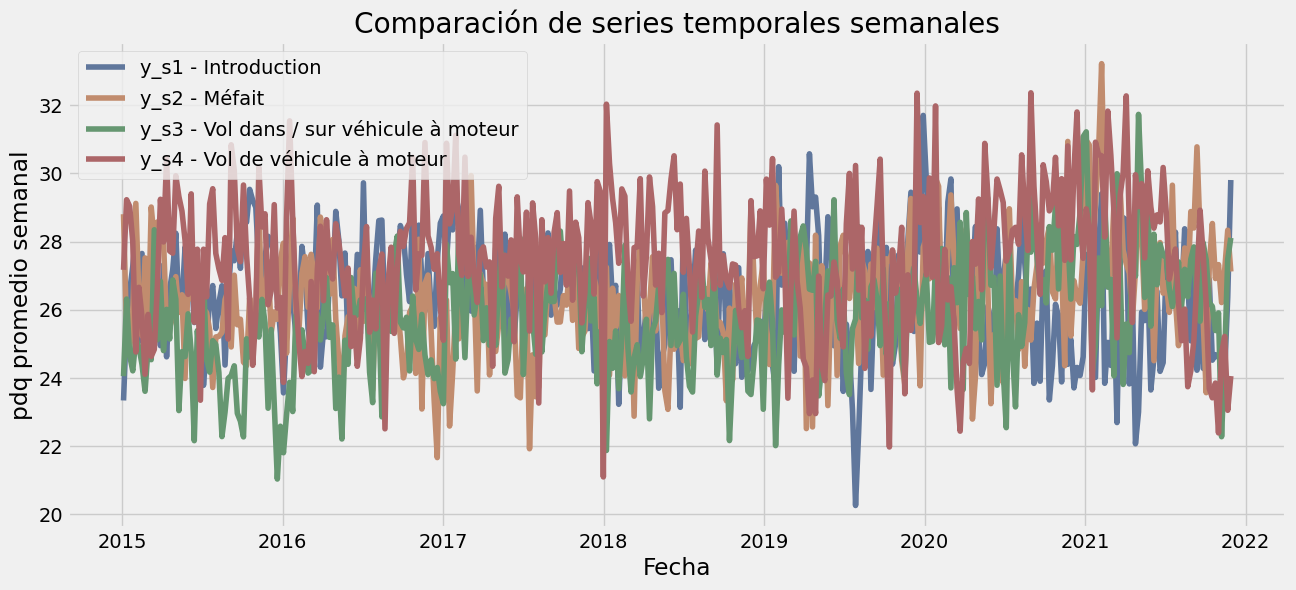

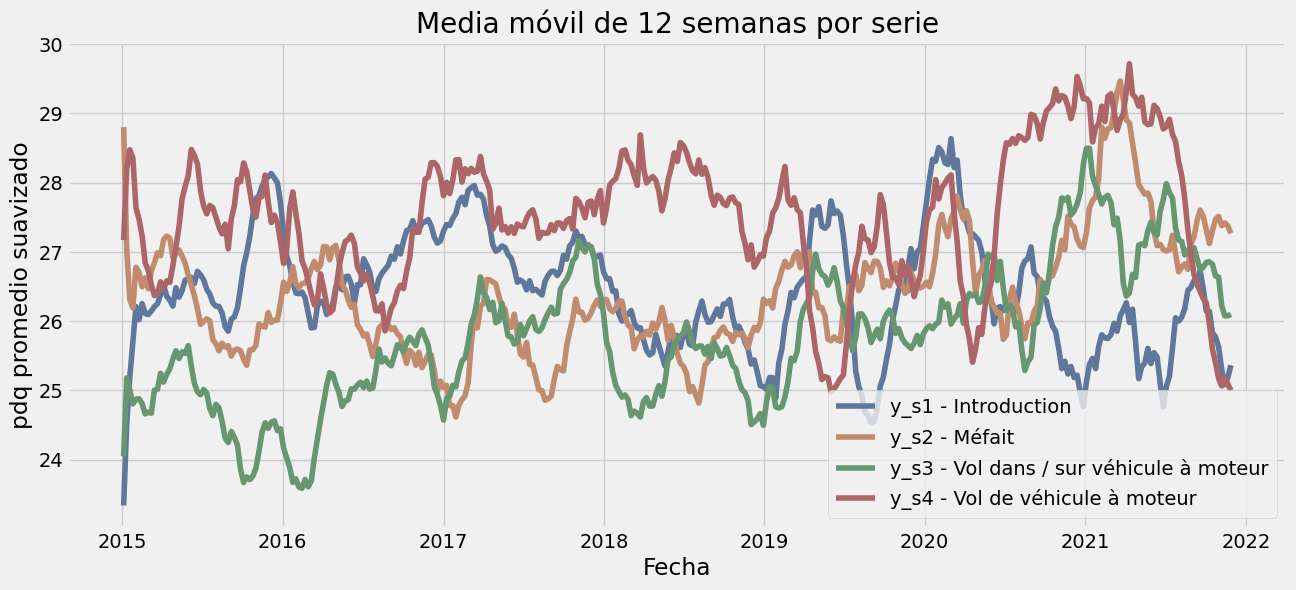

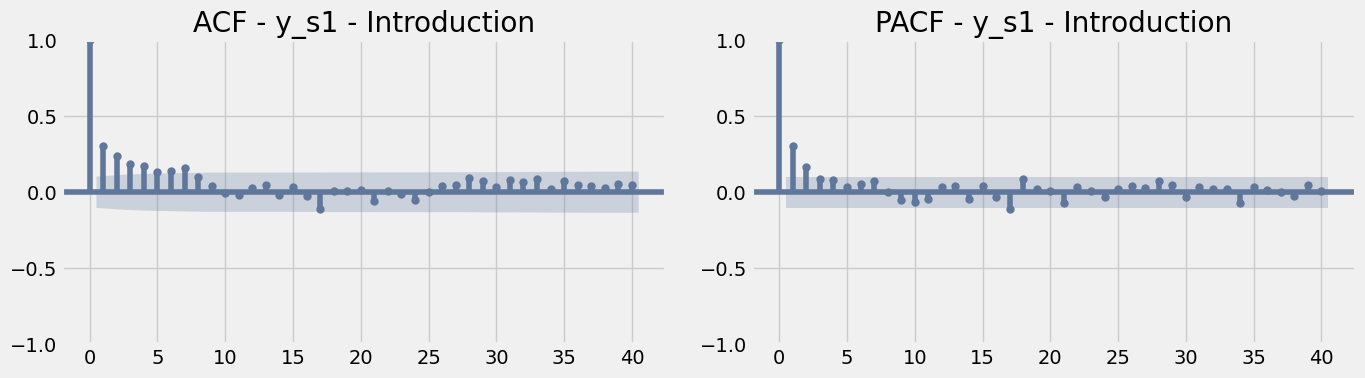

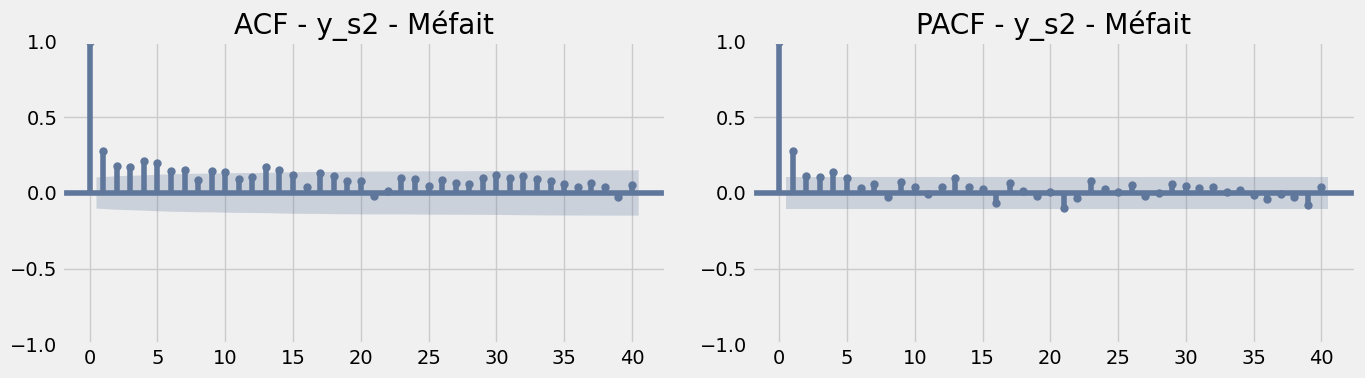

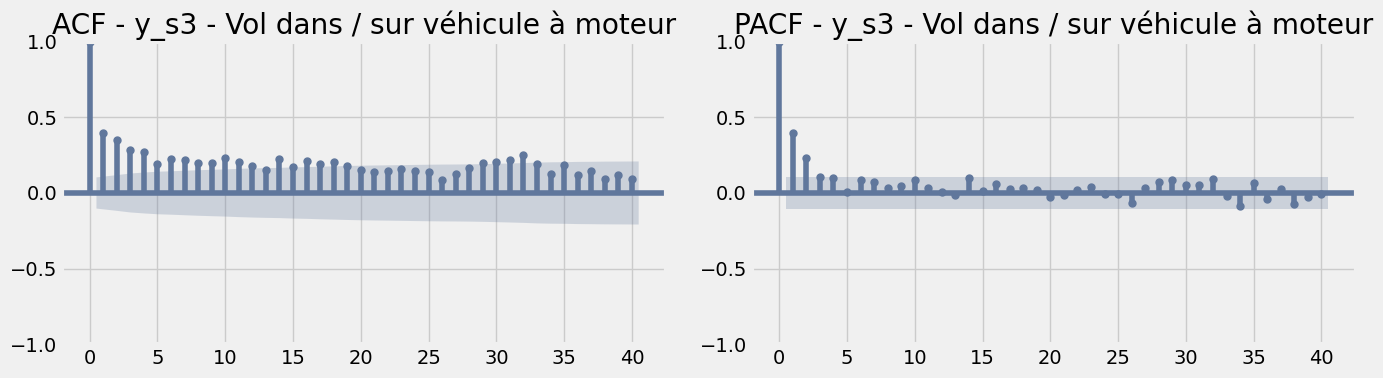

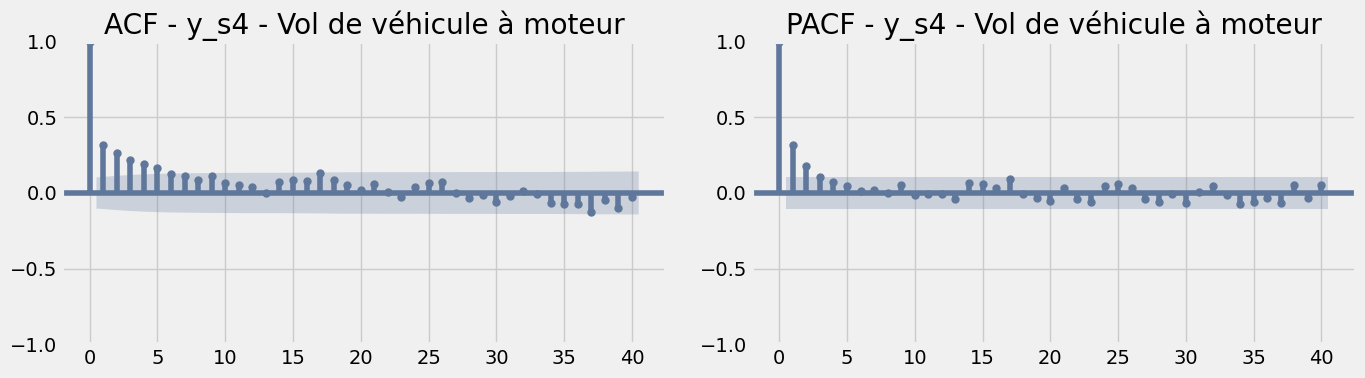

In [13]:
# 1. Visualización de las series temporales y_si, i=1,2,3,4

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

# Diccionario con las series semanales
series_dict = {
    "y_s1 - Introduction": y_s1,
    "y_s2 - Méfait": y_s2,
    "y_s3 - Vol dans / sur véhicule à moteur": y_s3,
    "y_s4 - Vol de véhicule à moteur": y_s4,
}

# Revisar rango temporal y cantidad de observaciones
resumen_series = []

for nombre, serie in series_dict.items():
    resumen_series.append({
        "serie": nombre,
        "fecha_inicio": serie.index.min(),
        "fecha_fin": serie.index.max(),
        "observaciones": serie.shape[0],
        "nulos": serie["pdq"].isnull().sum(),
        "promedio": serie["pdq"].mean(),
        "minimo": serie["pdq"].min(),
        "maximo": serie["pdq"].max()
    })

resumen_series = pd.DataFrame(resumen_series)
display(resumen_series)

# Gráfico individual de cada serie temporal
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, (nombre, serie) in zip(axes, series_dict.items()):
    serie["pdq"].plot(ax=ax, linewidth=1.5)
    ax.set_title(nombre)
    ax.set_ylabel("pdq")
    ax.grid(True)

plt.suptitle("Series temporales semanales por categoría de delito", fontsize=16)
plt.tight_layout()
plt.show()

# Gráfico comparativo de las cuatro series
plt.figure(figsize=(14, 6))

for nombre, serie in series_dict.items():
    plt.plot(serie.index, serie["pdq"], label=nombre)

plt.title("Comparación de series temporales semanales")
plt.xlabel("Fecha")
plt.ylabel("pdq promedio semanal")
plt.legend()
plt.grid(True)
plt.show()

# Suavizamiento con media móvil de 12 semanas
plt.figure(figsize=(14, 6))

for nombre, serie in series_dict.items():
    rolling = serie["pdq"].rolling(window=12, min_periods=1).mean()
    plt.plot(serie.index, rolling, label=nombre)

plt.title("Media móvil de 12 semanas por serie")
plt.xlabel("Fecha")
plt.ylabel("pdq promedio suavizado")
plt.legend()
plt.grid(True)
plt.show()

# ACF y PACF para observar dependencia temporal en cada serie
for nombre, serie in series_dict.items():
    serie_limpia = serie["pdq"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(serie_limpia, lags=40, ax=axes[0])
    axes[0].set_title(f"ACF - {nombre}")

    plot_pacf(serie_limpia, lags=40, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF - {nombre}")

    plt.tight_layout()
    plt.show()

En este primer punto se visualizaron las cuatro series temporales semanales correspondientes a las categorías `Introduction`, `Méfait`, `Vol dans / sur véhicule à moteur` y `Vol de véhicule à moteur`. Todas las series tienen el mismo período de análisis, desde el **4 de enero de 2015** hasta el **28 de noviembre de 2021**, con **361 observaciones semanales** y sin valores nulos.

Los promedios semanales de las series son relativamente parecidos. La serie `Introduction` tiene un promedio de **26,44**, `Méfait` de **26,39**, `Vol dans / sur véhicule à moteur` de **25,79** y `Vol de véhicule à moteur` de **27,46**. Esto indica que, en promedio, las cuatro categorías presentan niveles similares de actividad semanal en la variable `pdq`.

En cuanto a los rangos, `Méfait` alcanza el máximo más alto, con **33,22**, mientras que `Introduction` presenta un máximo de **31,70**, `Vol dans / sur véhicule à moteur` de **31,73** y `Vol de véhicule à moteur` de **32,37**. Los mínimos también se mantienen dentro de un rango relativamente acotado, entre aproximadamente **20,26** y **21,66**.

Los gráficos de las series y las medias móviles permiten observar fluctuaciones semanales y posibles patrones de tendencia o estacionalidad. En general, las series no muestran un crecimiento permanente muy marcado, sino variaciones en torno a un nivel medio relativamente estable. Sin embargo, las oscilaciones sugieren que puede existir dependencia temporal, por lo que resulta adecuado aplicar modelos de series temporales como SARIMA y Prophet.



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



In [14]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'

Serie seleccionada: Introduction
Rango temporal: 2015-01-04 00:00:00 a 2021-11-28 00:00:00
Cantidad de observaciones: 361
Valores nulos: 0


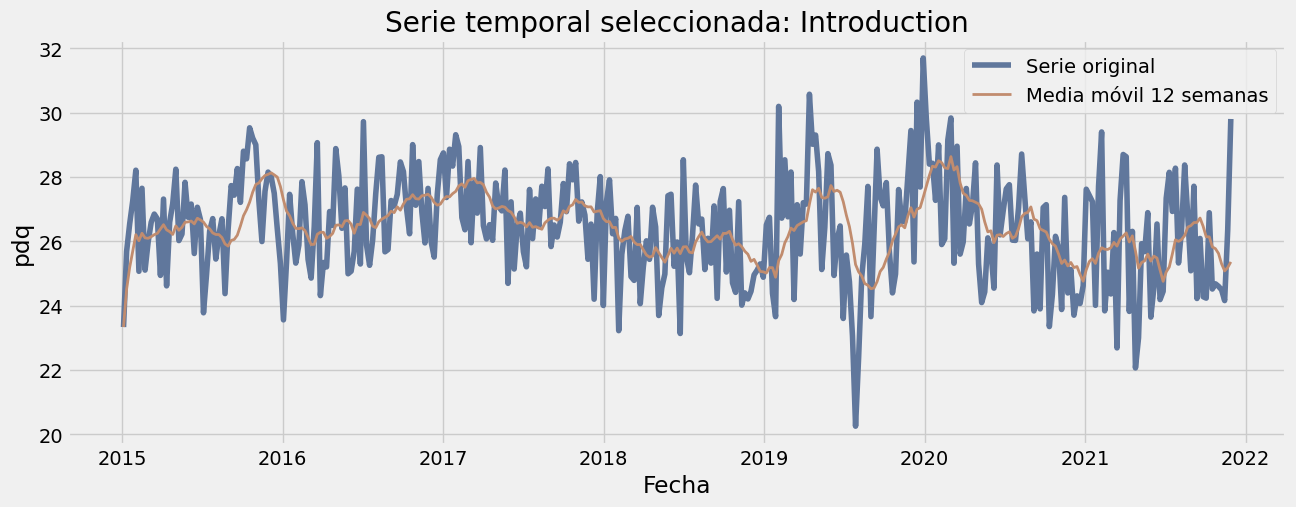

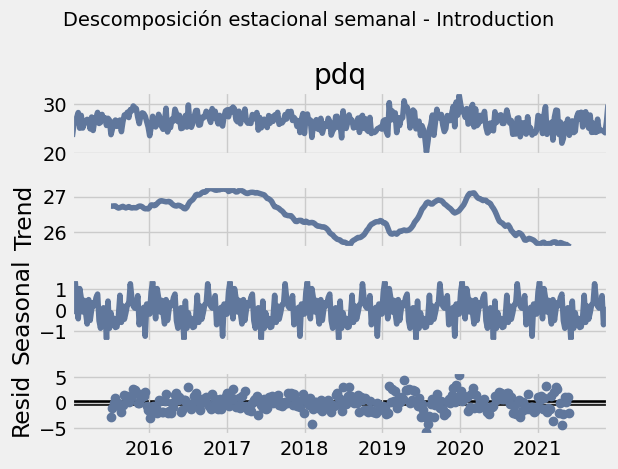

Tamaño train: (313, 1)
Tamaño test: (48, 1)
Fecha de corte efectiva: 2021-01-01


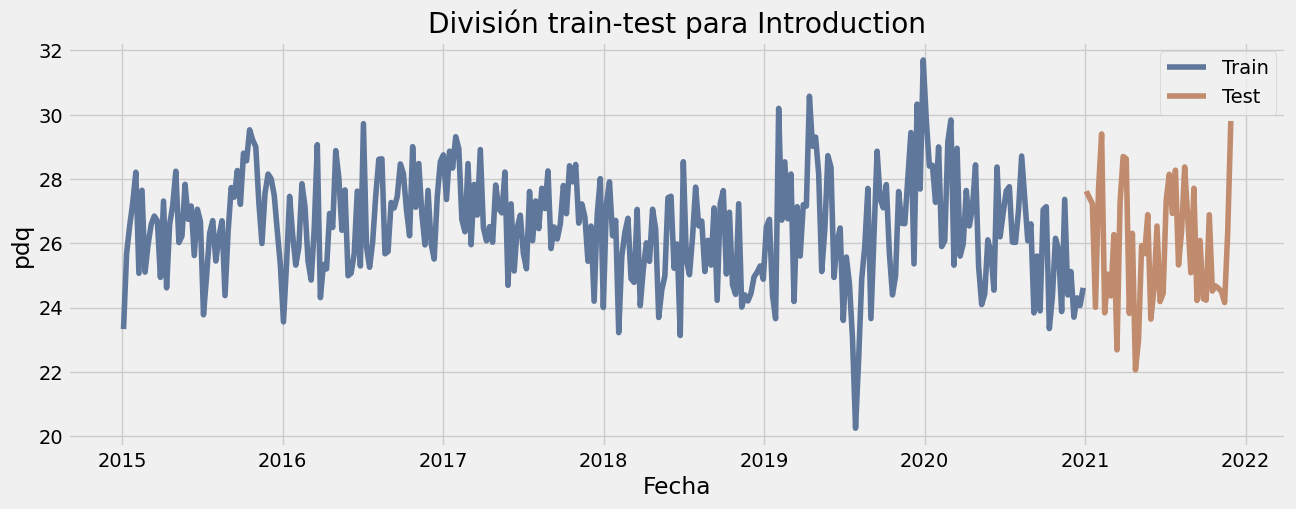

Resultados SARIMA ordenados por RMSE:


,mae,mse,rmse,mape,maape,wmape,mmape,smape,model,order,seasonal_order,aic,bic
0,1.7325,4.7111,2.1705,0.0646,0.0643,0.0670,0.0622,0.0671,"SARIMA_(1,1,1)X(0,0,1,52)","(1, 1, 1)","(0, 0, 1, 52)",965.490940,979.702778
1,1.7335,4.7229,2.1732,0.0646,0.0644,0.0670,0.0623,0.0672,"SARIMA_(1,1,1)X(0,0,0,52)","(1, 1, 1)","(0, 0, 0, 52)",1140.376487,1151.586204
2,1.8393,4.7898,2.1886,0.0725,0.0721,0.0711,0.0697,0.0708,"SARIMA_(1,0,1)X(0,1,1,52)","(1, 0, 1)","(0, 1, 1, 52)",818.347900,831.678776
3,1.7987,4.8825,2.2096,0.0716,0.0712,0.0695,0.0688,0.0692,"SARIMA_(0,0,0)X(0,1,1,52)","(0, 0, 0)","(0, 1, 1, 52)",869.763005,876.438081
4,1.7492,4.8874,2.2107,0.0650,0.0648,0.0676,0.0627,0.0678,"SARIMA_(0,1,1)X(0,0,1,52)","(0, 1, 1)","(0, 0, 1, 52)",963.814340,974.473218
5,1.7498,4.8931,2.2120,0.0651,0.0648,0.0676,0.0627,0.0678,"SARIMA_(0,1,1)X(1,0,0,52)","(0, 1, 1)","(1, 0, 0, 52)",972.630869,983.312914
6,1.8065,4.8952,2.2125,0.0719,0.0715,0.0698,0.0691,0.0695,"SARIMA_(0,0,1)X(0,1,1,52)","(0, 0, 1)","(0, 1, 1, 52)",845.410553,855.408710
7,1.8102,4.9050,2.2147,0.0720,0.0716,0.0700,0.0692,0.0696,"SARIMA_(1,0,0)X(0,1,1,52)","(1, 0, 0)","(0, 1, 1, 52)",837.101374,847.113988
8,1.7565,4.9602,2.2272,0.0653,0.0650,0.0679,0.0629,0.0681,"SARIMA_(0,1,0)X(0,0,0,52)","(0, 1, 0)","(0, 0, 0, 52)",1272.472818,1276.212611
9,1.7571,4.9661,2.2285,0.0653,0.0650,0.0679,0.0629,0.0681,"SARIMA_(0,1,1)X(0,0,0,52)","(0, 1, 1)","(0, 0, 0, 52)",1139.221268,1146.694412


Mejor modelo SARIMA:


,0
mae,1.7325
mse,4.7111
rmse,2.1705
mape,0.0646
maape,0.0643
wmape,0.067
mmape,0.0622
smape,0.0671
model,"SARIMA_(1,1,1)X(0,0,1,52)"
order,"(1, 1, 1)"


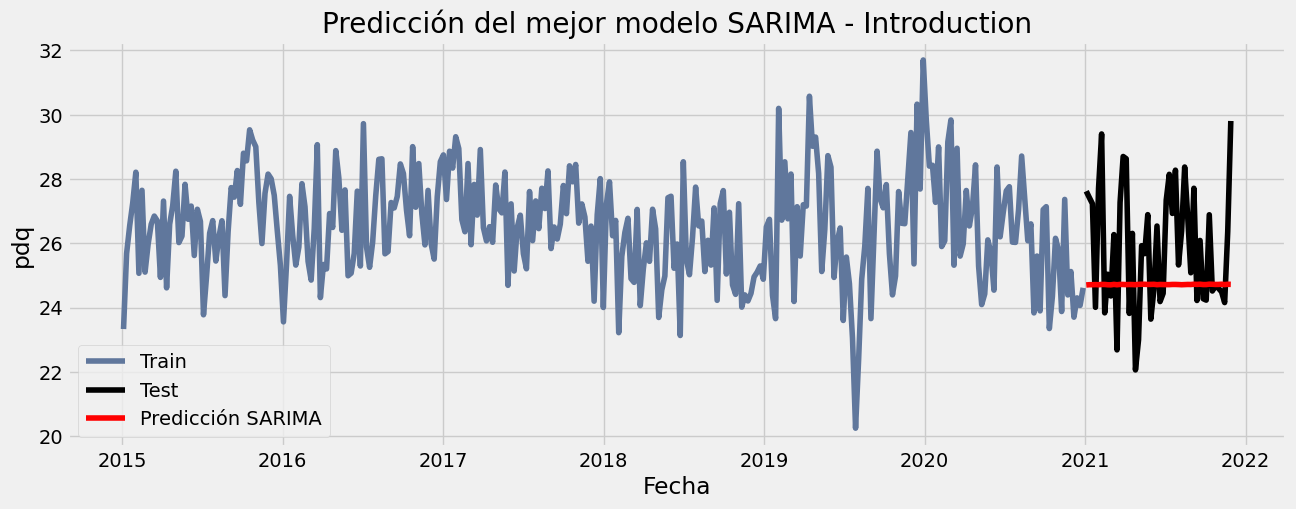

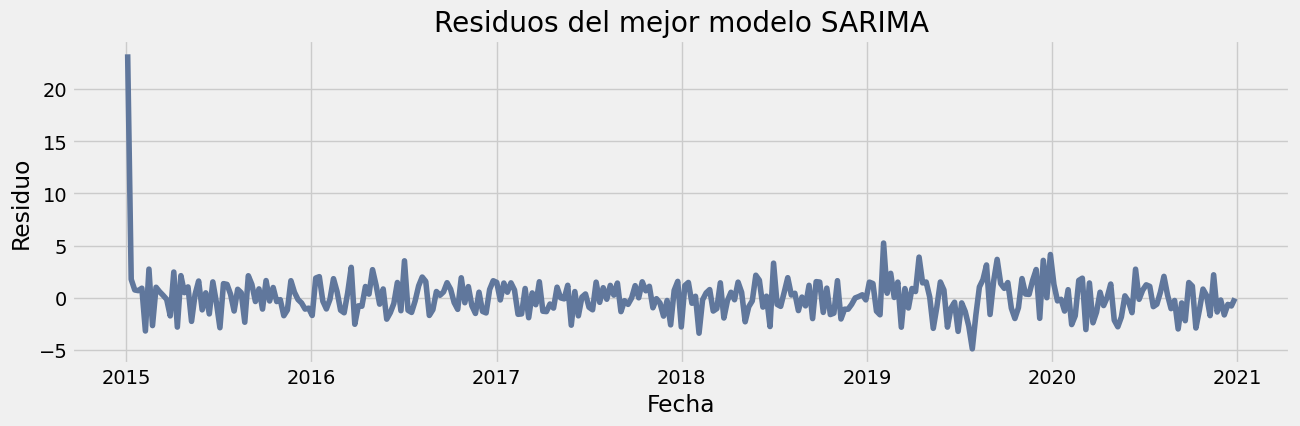

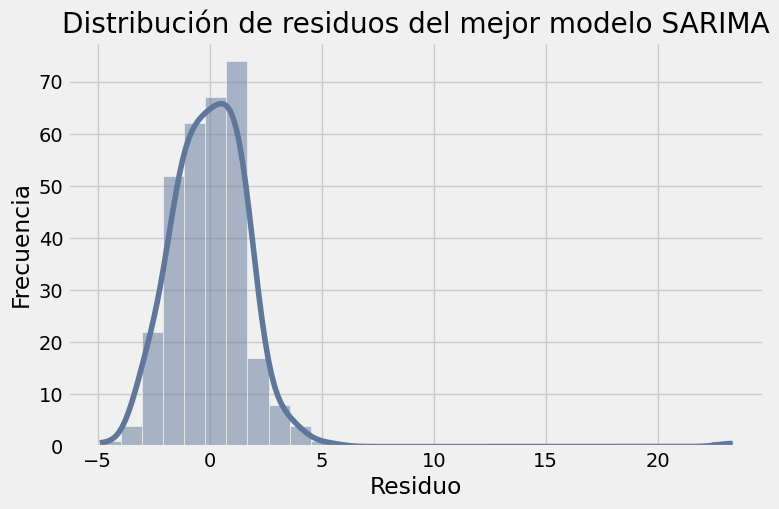

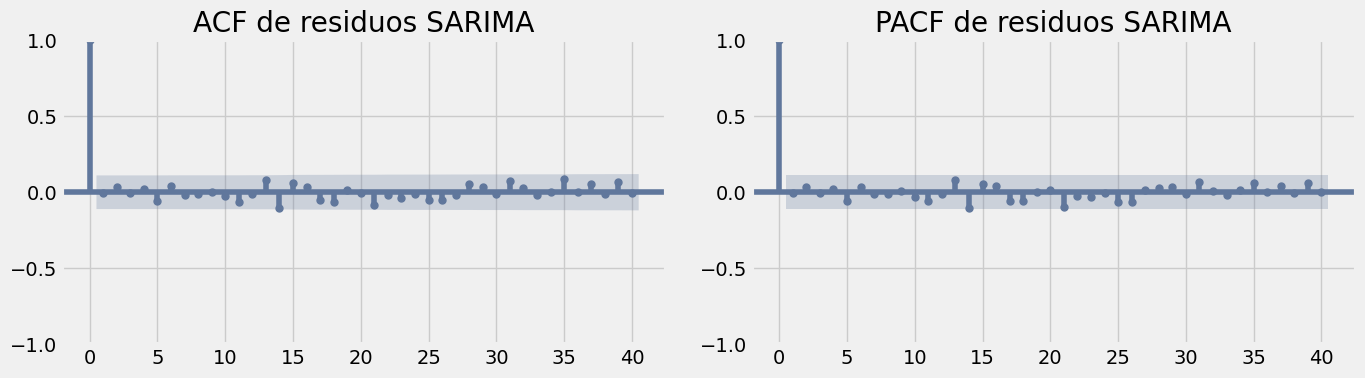

Prueba Ljung-Box sobre residuos:


,lb_stat,lb_pvalue
10,2.453714,0.991533
20,13.437464,0.857836
30,20.096779,0.913997


No se rechaza H0: no hay evidencia de autocorrelación significativa en los residuos.


In [7]:
# 2. Selección de una serie temporal y modelado SARIMA

from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# Seleccionar una serie para modelar.
# Puedes cambiar y_s1 por y_s2, y_s3 o y_s4 si quieres analizar otra categoría.
serie_seleccionada = y_s1.copy()
nombre_serie = "Introduction"

# Asegurar frecuencia semanal e imputar posibles nulos por interpolación temporal
serie_seleccionada = serie_seleccionada.asfreq("W")
serie_seleccionada["pdq"] = serie_seleccionada["pdq"].interpolate(method="time").ffill().bfill()

print("Serie seleccionada:", nombre_serie)
print("Rango temporal:", serie_seleccionada.index.min(), "a", serie_seleccionada.index.max())
print("Cantidad de observaciones:", len(serie_seleccionada))
print("Valores nulos:", serie_seleccionada["pdq"].isnull().sum())

# Análisis exploratorio de la serie seleccionada
plt.figure(figsize=(14, 5))
plt.plot(serie_seleccionada.index, serie_seleccionada["pdq"], label="Serie original")
plt.plot(
    serie_seleccionada.index,
    serie_seleccionada["pdq"].rolling(window=12, min_periods=1).mean(),
    label="Media móvil 12 semanas",
    linewidth=2
)
plt.title(f"Serie temporal seleccionada: {nombre_serie}")
plt.xlabel("Fecha")
plt.ylabel("pdq")
plt.legend()
plt.grid(True)
plt.show()

# Descomposición estacional aproximada con periodo 52 semanas
# Se usa 52 porque la serie está agregada semanalmente.
if len(serie_seleccionada) >= 104:
    decomposition = seasonal_decompose(
        serie_seleccionada["pdq"],
        model="additive",
        period=52
    )
    decomposition.plot()
    plt.suptitle(f"Descomposición estacional semanal - {nombre_serie}", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes observaciones para una descomposición anual de 52 semanas.")

# División train-test con target_date solicitado
target_date = "2021-01-01"

y_train, y_test = SarimaModels.test_train_model(serie_seleccionada, target_date)

# Si por alguna razón no queda conjunto test, se usa el último 20% como respaldo.
# Esto permite que el notebook siga funcionando en caso de que el dataset descargado tenga menos fechas.
if len(y_test) == 0:
    print("Advertencia: con target_date no quedó conjunto test. Se usará el último 20% como respaldo.")
    split_idx = int(len(serie_seleccionada) * 0.8)
    y_train = serie_seleccionada.iloc[:split_idx]
    y_test = serie_seleccionada.iloc[split_idx:]
    target_date_efectivo = y_test.index.min()
else:
    target_date_efectivo = target_date

print("Tamaño train:", y_train.shape)
print("Tamaño test:", y_test.shape)
print("Fecha de corte efectiva:", target_date_efectivo)

plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train["pdq"], label="Train")
plt.plot(y_test.index, y_test["pdq"], label="Test")
plt.title(f"División train-test para {nombre_serie}")
plt.xlabel("Fecha")
plt.ylabel("pdq")
plt.legend()
plt.grid(True)
plt.show()

# Búsqueda de hiperparámetros SARIMA
# Para series semanales es razonable probar estacionalidad anual S=52.
# Para mantener el tiempo de ejecución controlado, se prueba una grilla reducida.
p = d = q = range(0, 2)
pdq_grid = list(itertools.product(p, d, q))

seasonal_pdq_grid = [
    (0, 0, 0, 52),
    (1, 0, 0, 52),
    (0, 1, 0, 52),
    (0, 0, 1, 52),
    (1, 1, 0, 52),
    (0, 1, 1, 52)
]

params_sarima = list(itertools.product(pdq_grid, seasonal_pdq_grid))

resultados_sarima = []
modelos_ajustados = {}

for param in params_sarima:
    try:
        modelo = SarimaModels(param)
        ajuste = modelo.fit_model(serie_seleccionada, target_date_efectivo)
        df_pred = modelo.df_testig(serie_seleccionada, target_date_efectivo)

        # Eliminar posibles nulos de predicción
        df_pred = df_pred.dropna()

        if len(df_pred) == 0:
            continue

        metricas = summary_metrics(df_pred)
        metricas["model"] = modelo.name_model
        metricas["order"] = str(param[0])
        metricas["seasonal_order"] = str(param[1])
        metricas["aic"] = ajuste.aic
        metricas["bic"] = ajuste.bic

        resultados_sarima.append(metricas)
        modelos_ajustados[modelo.name_model] = {
            "modelo": modelo,
            "ajuste": ajuste,
            "predicciones": df_pred,
            "params": param
        }

    except Exception:
        # Algunos modelos pueden no converger; se omiten.
        pass

resultados_sarima = pd.concat(resultados_sarima, ignore_index=True)
resultados_sarima = resultados_sarima.sort_values(["rmse", "mae"]).reset_index(drop=True)

print("Resultados SARIMA ordenados por RMSE:")
display(resultados_sarima.head(15))

# Seleccionar mejor modelo por RMSE
mejor_fila_sarima = resultados_sarima.iloc[0]
mejor_modelo_nombre = mejor_fila_sarima["model"]
mejor_info = modelos_ajustados[mejor_modelo_nombre]

print("Mejor modelo SARIMA:")
display(mejor_fila_sarima)

mejor_ajuste = mejor_info["ajuste"]
df_pred_sarima = mejor_info["predicciones"]

# Gráfico de predicciones vs valores reales
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train["pdq"], label="Train")
plt.plot(y_test.index, y_test["pdq"], label="Test", color="black")
plt.plot(df_pred_sarima.index, df_pred_sarima["yhat"], label="Predicción SARIMA", color="red")
plt.title(f"Predicción del mejor modelo SARIMA - {nombre_serie}")
plt.xlabel("Fecha")
plt.ylabel("pdq")
plt.legend()
plt.grid(True)
plt.show()

# Residuos del mejor modelo
residuos = mejor_ajuste.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(residuos)
plt.title("Residuos del mejor modelo SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuos, kde=True, bins=30)
plt.title("Distribución de residuos del mejor modelo SARIMA")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuos, lags=40, ax=axes[0])
axes[0].set_title("ACF de residuos SARIMA")
plot_pacf(residuos, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF de residuos SARIMA")
plt.tight_layout()
plt.show()

# Prueba Ljung-Box para evaluar ruido blanco
ljung_box = acorr_ljungbox(residuos, lags=[10, 20, 30], return_df=True)

print("Prueba Ljung-Box sobre residuos:")
display(ljung_box)

if (ljung_box["lb_pvalue"] > 0.05).all():
    print("No se rechaza H0: no hay evidencia de autocorrelación significativa en los residuos.")
else:
    print("Se rechaza H0 en al menos un rezago: puede existir autocorrelación remanente en los residuos.")

Para el modelado SARIMA se seleccionó la serie `Introduction`. Esta serie contiene **361 observaciones semanales**, desde el **4 de enero de 2015** hasta el **28 de noviembre de 2021**, sin valores nulos. La serie fue dividida en un conjunto de entrenamiento de **313 observaciones** y un conjunto de prueba de **48 observaciones**, utilizando como fecha de corte el **1 de enero de 2021**.

Se probaron distintas configuraciones SARIMA combinando componentes no estacionales y estacionales. La mejor configuración según RMSE fue:

**SARIMA(1,1,1) x (0,0,1,52)**

Este modelo obtuvo un **MAE de 1,7325**, un **RMSE de 2,1705**, un **MAPE de 0,0646** y un **SMAPE de 0,0671**. Esto significa que, en promedio, las predicciones se desvían aproximadamente **1,73 unidades** respecto del valor real, y el error porcentual promedio se encuentra cercano al **6,5%**.

La elección de un período estacional de **52 semanas** es coherente con la frecuencia semanal de los datos, ya que permite capturar posibles patrones anuales. Además, el modelo incluye diferenciación no estacional, lo que ayuda a estabilizar la serie y capturar cambios en el nivel temporal.

En comparación con otros modelos SARIMA evaluados, esta configuración fue la que presentó el menor RMSE, aunque las diferencias con los modelos siguientes no son demasiado grandes. Por ejemplo, el segundo mejor modelo tuvo un RMSE de **2,1732**, muy cercano al mejor resultado. Esto indica que varias configuraciones logran un desempeño similar, pero el modelo SARIMA(1,1,1)x(0,0,1,52) fue levemente superior en capacidad predictiva.

La validación de residuos permite evaluar si el modelo SARIMA capturó adecuadamente la estructura temporal de la serie. Para esto se analizaron los residuos mediante gráficos, ACF/PACF y la prueba de Ljung-Box.

Los resultados de la prueba de Ljung-Box muestran p-valores altos en los rezagos evaluados: **0,9915** para el rezago 10, **0,8578** para el rezago 20 y **0,9140** para el rezago 30. Como todos estos valores son mayores a 0,05, no se rechaza la hipótesis nula de ausencia de autocorrelación en los residuos.

Esto significa que no existe evidencia estadística suficiente de autocorrelación significativa remanente en los errores del modelo. En términos simples, los residuos se comportan de forma similar a ruido blanco, lo cual es una señal positiva: el modelo logró capturar la mayor parte de la estructura temporal relevante de la serie.

Por lo tanto, el modelo SARIMA seleccionado no solo presenta un buen desempeño predictivo, sino que también muestra residuos razonablemente adecuados desde el punto de vista estadístico.




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


Tamaño train Prophet: (313, 2)
Tamaño test Prophet: (48, 2)
Métricas Prophet:


,mae,mse,rmse,mape,maape,wmape,mmape,smape,model
0,1.7059,4.1237,2.0307,0.0669,0.0666,0.0659,0.0644,0.0659,Prophet


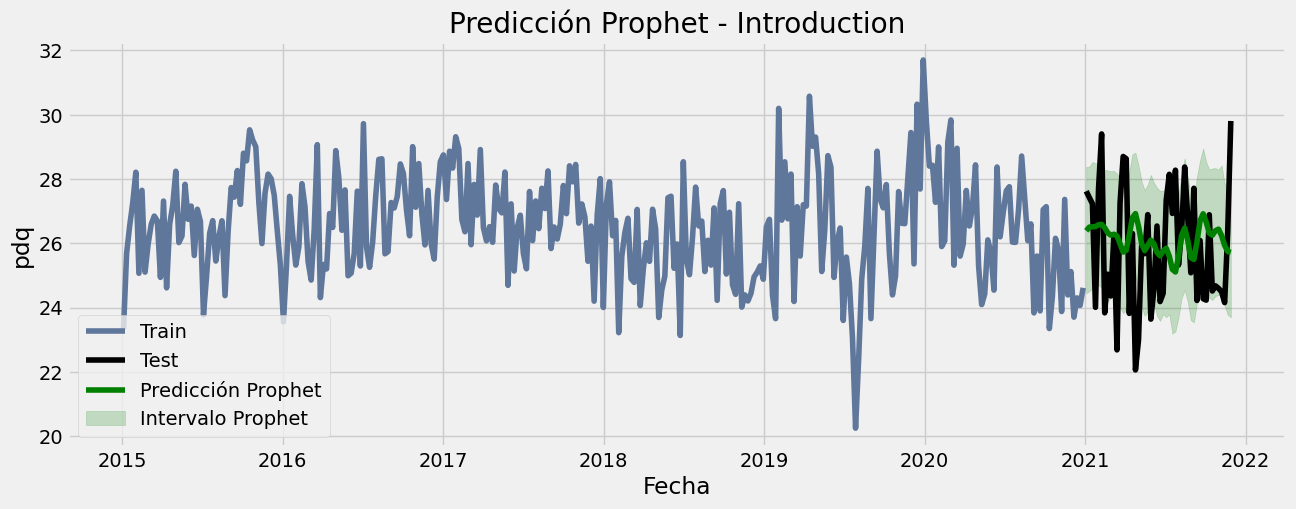

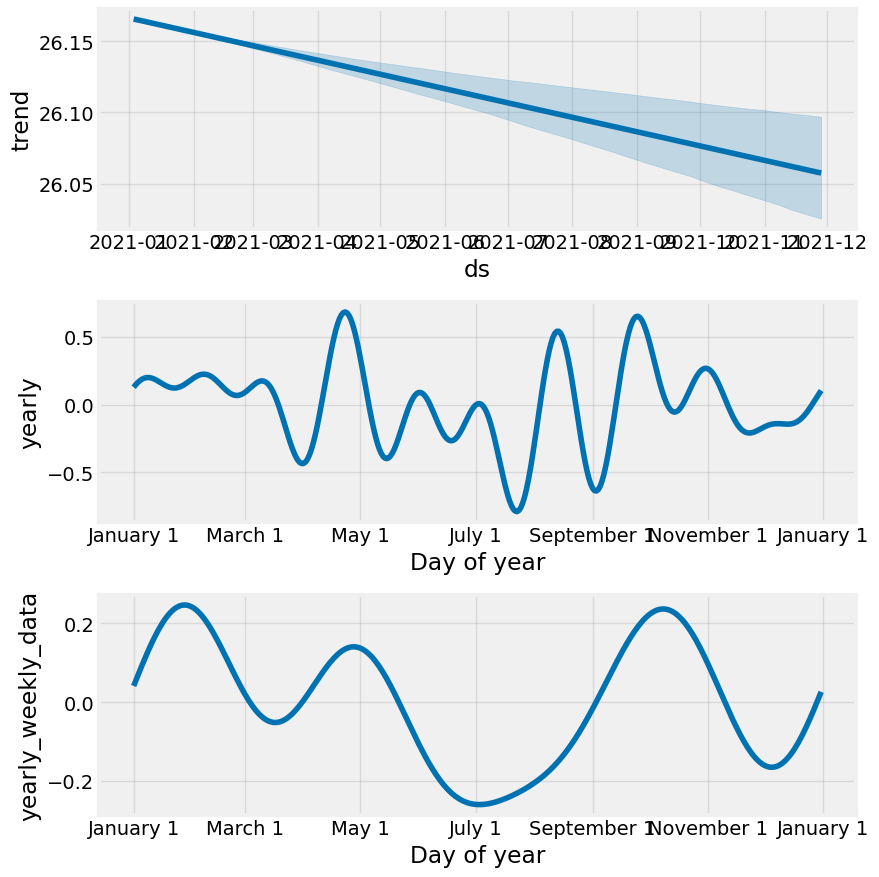

Comparación entre SARIMA y Prophet:


,model,mae,rmse,mape,wmape,smape
0,SARIMA - mejor configuración,1.7325,2.1705,0.0646,0.067,0.0671
1,Prophet,1.7059,2.0307,0.0669,0.0659,0.0659


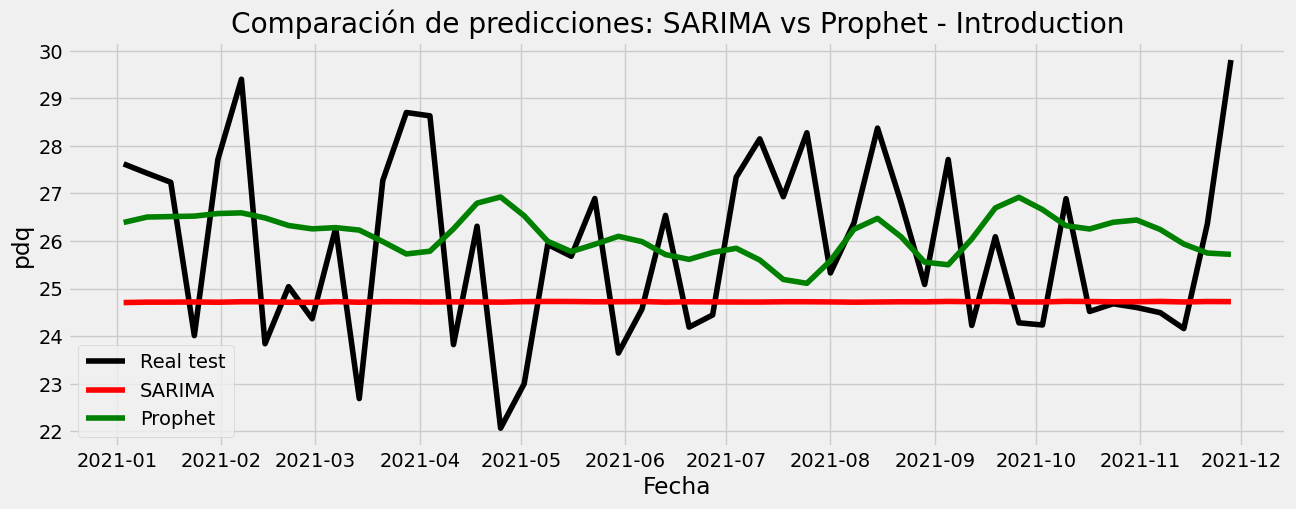

Mejor modelo según RMSE:


,1
mae,1.7059
mse,4.1237
rmse,2.0307
mape,0.0669
maape,0.0666
wmape,0.0659
mmape,0.0644
smape,0.0659
model,Prophet


In [15]:
# 3. Modelado con Prophet y comparación con SARIMA

# En Colab, si Prophet no está instalado, descomenta esta línea:
# !pip install prophet -q

from prophet import Prophet

# Preparar datos para Prophet.
# Prophet requiere columnas llamadas ds e y.
df_prophet = serie_seleccionada.reset_index().rename(
    columns={"date": "ds", "pdq": "y"}
)

# Asegurar formato correcto
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")
df_prophet = df_prophet.dropna(subset=["ds", "y"])

# División train-test usando la misma fecha efectiva de corte
mask_train = df_prophet["ds"] < pd.to_datetime(target_date_efectivo)

prophet_train = df_prophet.loc[mask_train].copy()
prophet_test = df_prophet.loc[~mask_train].copy()

if len(prophet_test) == 0:
    print("Advertencia: Prophet no tiene test con la fecha de corte. Se usará el último 20% como respaldo.")
    split_idx = int(len(df_prophet) * 0.8)
    prophet_train = df_prophet.iloc[:split_idx].copy()
    prophet_test = df_prophet.iloc[split_idx:].copy()

print("Tamaño train Prophet:", prophet_train.shape)
print("Tamaño test Prophet:", prophet_test.shape)

# Ajustar modelo Prophet
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

# Como la serie ya es semanal, se agrega una estacionalidad anual personalizada en semanas
modelo_prophet.add_seasonality(
    name="yearly_weekly_data",
    period=365.25,
    fourier_order=5
)

modelo_prophet.fit(prophet_train)

# Crear dataframe futuro con las fechas del test
future_test = prophet_test[["ds"]].copy()

forecast_test = modelo_prophet.predict(future_test)

df_pred_prophet = prophet_test[["ds", "y"]].merge(
    forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

df_pred_prophet_metrics = df_pred_prophet.rename(columns={"y": "y"})
df_pred_prophet_metrics = df_pred_prophet_metrics[["y", "yhat"]].dropna()

metricas_prophet = summary_metrics(df_pred_prophet_metrics)
metricas_prophet["model"] = "Prophet"

print("Métricas Prophet:")
display(metricas_prophet)

# Visualización de predicciones Prophet
plt.figure(figsize=(14, 5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test", color="black")
plt.plot(df_pred_prophet["ds"], df_pred_prophet["yhat"], label="Predicción Prophet", color="green")
plt.fill_between(
    df_pred_prophet["ds"],
    df_pred_prophet["yhat_lower"],
    df_pred_prophet["yhat_upper"],
    alpha=0.2,
    color="green",
    label="Intervalo Prophet"
)
plt.title(f"Predicción Prophet - {nombre_serie}")
plt.xlabel("Fecha")
plt.ylabel("pdq")
plt.legend()
plt.grid(True)
plt.show()

# Componentes del modelo Prophet
fig = modelo_prophet.plot_components(forecast_test)
plt.show()

# Comparación SARIMA vs Prophet
metricas_sarima_best = mejor_fila_sarima[["mae", "mse", "rmse", "mape", "maape", "wmape", "mmape", "smape", "model"]].to_frame().T
metricas_sarima_best["model"] = "SARIMA - mejor configuración"

comparacion_modelos = pd.concat(
    [metricas_sarima_best, metricas_prophet],
    ignore_index=True
)

print("Comparación entre SARIMA y Prophet:")
display(comparacion_modelos[["model", "mae", "rmse", "mape", "wmape", "smape"]])

# Gráfico comparativo de predicciones
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test["pdq"], label="Real test", color="black")
plt.plot(df_pred_sarima.index, df_pred_sarima["yhat"], label="SARIMA", color="red")
plt.plot(df_pred_prophet["ds"], df_pred_prophet["yhat"], label="Prophet", color="green")
plt.title(f"Comparación de predicciones: SARIMA vs Prophet - {nombre_serie}")
plt.xlabel("Fecha")
plt.ylabel("pdq")
plt.legend()
plt.grid(True)
plt.show()

# Selección del mejor modelo por RMSE
comparacion_modelos["rmse"] = pd.to_numeric(comparacion_modelos["rmse"], errors="coerce")
mejor_comparacion = comparacion_modelos.sort_values("rmse").iloc[0]

print("Mejor modelo según RMSE:")
display(mejor_comparacion)

Luego se ajustó un modelo Prophet sobre la misma serie seleccionada, `Introduction`, utilizando la misma división temporal. El conjunto de entrenamiento tuvo **313 observaciones** y el conjunto de prueba **48 observaciones**, lo que permite comparar sus resultados directamente con el modelo SARIMA.

El modelo Prophet obtuvo un **MAE de 1,7059**, un **RMSE de 2,0307**, un **MAPE de 0,0669**, un **WMAPE de 0,0659** y un **SMAPE de 0,0659**. Estos resultados muestran que Prophet tuvo una capacidad predictiva bastante buena, con errores porcentuales promedio cercanos al **6,6%**.

En términos de error absoluto, Prophet predice ligeramente mejor que SARIMA, ya que su MAE y RMSE son menores. Esto indica que, para esta serie y este período de prueba, Prophet logró ajustar mejor la evolución general de los datos.

Una ventaja de Prophet es que permite modelar de manera flexible tendencias y estacionalidades, además de generar intervalos de incertidumbre. Esto es útil cuando se trabaja con series temporales que pueden tener cambios de nivel o patrones estacionales.

Al comparar ambos modelos, se observa que Prophet obtuvo el mejor desempeño según RMSE. El modelo SARIMA seleccionado alcanzó un **MAE de 1,7325** y un **RMSE de 2,1705**, mientras que Prophet obtuvo un **MAE de 1,7059** y un **RMSE de 2,0307**.

Esto significa que Prophet redujo levemente el error de predicción respecto de SARIMA. En particular, el RMSE de Prophet fue menor, lo que indica que cometió errores grandes con menor intensidad que el modelo SARIMA. Además, Prophet también obtuvo un WMAPE y SMAPE levemente menores: **0,0659** frente a **0,0670** y **0,0671** en SARIMA.

Sin embargo, SARIMA tuvo un MAPE ligeramente menor, con **0,0646** frente a **0,0669** de Prophet. Esto muestra que la comparación no es absolutamente dominante en todas las métricas, pero considerando el RMSE, MAE, WMAPE y SMAPE, Prophet aparece como el modelo más conveniente para esta serie.

En conclusión, para la serie `Introduction`, Prophet fue el mejor modelo según RMSE, mientras que SARIMA también presentó un desempeño competitivo y residuos estadísticamente adecuados. Esto sugiere que ambos modelos son útiles, pero Prophet entregó una ventaja predictiva leve en el conjunto de prueba utilizado.

El laboratorio permitió analizar y modelar series temporales semanales de delitos en Montreal, utilizando visualización exploratoria, modelos SARIMA y Prophet. Primero, se revisaron cuatro categorías de delitos y se observó que todas tenían 361 observaciones semanales, sin valores nulos y con niveles promedio relativamente similares.

Para el modelado se seleccionó la serie `Introduction`. Esta serie fue dividida en entrenamiento y prueba usando como corte el 1 de enero de 2021. En el enfoque SARIMA se probaron distintas configuraciones, y el mejor modelo fue **SARIMA(1,1,1)x(0,0,1,52)**, con un RMSE de **2,1705** y un MAPE cercano al **6,46%**. Además, la prueba de Ljung-Box indicó que los residuos no presentaban autocorrelación significativa, lo que valida razonablemente el ajuste del modelo.

Posteriormente, se aplicó Prophet sobre la misma serie y división temporal. Prophet obtuvo un RMSE de **2,0307**, un MAE de **1,7059** y un SMAPE de **0,0659**, superando levemente al modelo SARIMA en varias métricas de error.

En síntesis, ambos modelos entregaron resultados adecuados para la predicción de la serie `Introduction`. SARIMA mostró una estructura estadística sólida y residuos bien comportados, mientras que Prophet ofreció un desempeño predictivo ligeramente superior. Por lo tanto, para esta serie específica, Prophet puede considerarse el modelo más conveniente según RMSE, aunque SARIMA sigue siendo una alternativa válida e interpretable para el análisis de series temporales.